# NB03 — Clinical-Covariate-Only Ecotype Classifier (H1c)

**Project**: `ibd_phage_targeting` — Pillar 1 closure
**Depends on**: NB01b (`data/ecotype_assignments.tsv`), NB02 (`data/ucdavis_kuehl_ecotype_projection.tsv`)

## Purpose

Test **H1c**: can ecotype be predicted from **clinical covariates alone** — demographics, severity markers, medication — without metagenomics? If yes at AUC ≥ 0.70, then ecotype assignment can be a routine clinical step, not something that requires stool WGS. If no, metagenomics is required for assignment.

Then apply the trained classifier to **UC Davis patients** and compare clinical-only ecotype predictions against the metagenomic LDA calls from NB02. Agreement tells us whether the two data modalities give congruent patient-stratification signals (an internal validation).

## Coverage reality

Clinical covariate coverage for the 8,489 reference samples is sparse (directly probed from the mart):

- Sex: 31 % (2,647 samples)
- Age at enrollment: 21 % (1,786 samples)
- HBI / SCCAI / calprotectin: 6-16 %
- Structured medication flags (`antibiotic_use`, `immunosuppressant_use`, `mesalamine_use`, `steroid_use`): 0 % — these are Franzosa-only flags in `dim_participants` and Franzosa samples are in `fact_metabolomics`, not `fact_taxon_abundance`.

**Therefore**: the realistic H1c test is a **minimal classifier** using study-provenance (CMD_HEALTHY vs CMD_IBD = HC vs IBD), sex, and age — plus severity markers on the subset that has them. This is honest; we report the AUC explicitly with the N available.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    from sklearn.ensemble import GradientBoostingClassifier

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')


## 1. Assemble feature matrix

Join `data/ecotype_assignments.tsv` (NB01b) with `dim_samples` + `dim_participants` + `fact_clinical_longitudinal`. Per sample: study, diagnosis, sex, age, and best-available severity markers (HBI / SCCAI / calprotectin max across the patient's visits).


In [2]:
eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
parts = pd.read_parquet(DATA_MART / 'dim_participants.snappy.parquet')
clin = pd.read_parquet(DATA_MART / 'fact_clinical_longitudinal.snappy.parquet')

# Per-participant clinical summary — max severity markers across their timeline
clin_by_pid = clin.groupby('participant_id').agg(
    hbi_max=('hbi','max'),
    sccai_max=('sccai','max'),
    calp_max=('calprotectin','max'),
).reset_index()

# Build the feature frame
feat = eco.merge(samples[['sample_id','participant_id','study_id']], on='sample_id', how='left')
feat = feat.merge(parts[['participant_id','age_at_enrollment','age_at_diagnosis','sex']],
                  on='participant_id', how='left')
feat = feat.merge(clin_by_pid, on='participant_id', how='left')

# Derived features
# - Is IBD? (binary from study_id)
feat['is_ibd'] = (feat.study_id == 'CMD_IBD').astype(int)
# - Sex encoded
feat['sex_male'] = feat.sex.map({'male': 1, 'Male': 1, 'M': 1, 'female': 0, 'Female': 0, 'F': 0})
# - Age (use age_at_enrollment, fall back to age_at_diagnosis)
feat['age'] = feat.age_at_enrollment.fillna(feat.age_at_diagnosis)
feat['age'] = pd.to_numeric(feat.age, errors='coerce')

print(f'Feature frame: {len(feat):,} rows')
print()
print('Per-feature coverage:')
for col in ['is_ibd','sex_male','age','hbi_max','sccai_max','calp_max']:
    cov = feat[col].notna().sum()
    print(f'  {col:<12} {cov:>6,} ({cov/len(feat):.0%})')
print()
print('Ecotype × is_ibd distribution:')
print(pd.crosstab(feat.consensus_ecotype, feat.is_ibd, margins=True).to_string())


Feature frame: 8,489 rows

Per-feature coverage:
  is_ibd        8,489 (100%)
  sex_male      2,647 (31%)
  age           1,879 (22%)
  hbi_max         848 (10%)
  sccai_max       477 (6%)
  calp_max      1,386 (16%)

Ecotype × is_ibd distribution:
is_ibd                0     1   All
consensus_ecotype                  
0                  3560    44  3604
1                   759  1842  2601
2                   900    20   920
3                   114  1250  1364
All                5333  3156  8489


## 2. Minimal classifier — features available on most samples

Features: `is_ibd`, `sex_male`, `age`. Impute missing with median/mode. This is the *widest-coverage* classifier we can train.


In [3]:
# Minimal feature set
min_feats = ['is_ibd','sex_male','age']
X_min = feat[min_feats].copy()
y = feat['consensus_ecotype'].values

# Impute
imputer = SimpleImputer(strategy='median')
X_min_imp = pd.DataFrame(imputer.fit_transform(X_min), columns=min_feats, index=feat.index)

print(f'Minimal feature matrix: {X_min_imp.shape}')
print(f'Ecotype balance: {pd.Series(y).value_counts().sort_index().to_dict()}')

# Model
if LGB_AVAILABLE:
    model_min = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                    random_state=42, n_jobs=1, verbose=-1)
else:
    model_min = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
# 5-fold stratified CV prediction (probabilities)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_min = cross_val_predict(model_min, X_min_imp, y, cv=skf, method='predict_proba', n_jobs=1)

# OvR AUCs
K = y_prob_min.shape[1]
auc_min = {}
for k in range(K):
    y_bin = (y == k).astype(int)
    auc_min[k] = roc_auc_score(y_bin, y_prob_min[:, k])
macro_min = np.mean(list(auc_min.values()))
print(f'\nMinimal classifier OvR AUCs (5-fold CV):')
for k in range(K):
    print(f'  Ecotype {k}: AUC = {auc_min[k]:.3f}')
print(f'  Macro-average: {macro_min:.3f}')


Minimal feature matrix: (8489, 3)
Ecotype balance: {0: 3604, 1: 2601, 2: 920, 3: 1364}



Minimal classifier OvR AUCs (5-fold CV):
  Ecotype 0: AUC = 0.812
  Ecotype 1: AUC = 0.792
  Ecotype 2: AUC = 0.695
  Ecotype 3: AUC = 0.895
  Macro-average: 0.799


## 3. Extended classifier — restricted to samples with severity markers

For the subset with HBI / SCCAI / calprotectin available, include them as features. This is the *upper-bound* classifier.


In [4]:
# Extended feature set — only rows with at least one severity marker
severity_feats = ['hbi_max','sccai_max','calp_max']
has_severity = feat[severity_feats].notna().any(axis=1)
feat_ext = feat[has_severity].copy()
X_ext = feat_ext[min_feats + severity_feats].copy()
y_ext = feat_ext['consensus_ecotype'].values

# Impute — median across ext subset
X_ext_imp = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_ext),
                         columns=min_feats + severity_feats, index=feat_ext.index)
print(f'Extended feature matrix: {X_ext_imp.shape}')
print(f'Ecotype balance: {pd.Series(y_ext).value_counts().sort_index().to_dict()}')

if LGB_AVAILABLE:
    model_ext = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                    random_state=42, n_jobs=1, verbose=-1)
else:
    model_ext = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)

skf_ext = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_ext = cross_val_predict(model_ext, X_ext_imp, y_ext, cv=skf_ext, method='predict_proba', n_jobs=1)

auc_ext = {}
for k in range(y_prob_ext.shape[1]):
    y_bin = (y_ext == k).astype(int)
    if y_bin.sum() > 0 and y_bin.sum() < len(y_bin):
        auc_ext[k] = roc_auc_score(y_bin, y_prob_ext[:, k])
    else:
        auc_ext[k] = np.nan
macro_ext = np.nanmean(list(auc_ext.values()))
print(f'\nExtended classifier OvR AUCs (5-fold CV, n={len(feat_ext):,}):')
for k in range(y_prob_ext.shape[1]):
    print(f'  Ecotype {k}: AUC = {auc_ext[k]:.3f}')
print(f'  Macro-average: {macro_ext:.3f}')


Extended feature matrix: (1675, 6)
Ecotype balance: {0: 3, 1: 702, 2: 11, 3: 959}



Extended classifier OvR AUCs (5-fold CV, n=1,675):
  Ecotype 0: AUC = 0.605
  Ecotype 1: AUC = 0.891
  Ecotype 2: AUC = 0.852
  Ecotype 3: AUC = 0.893
  Macro-average: 0.810


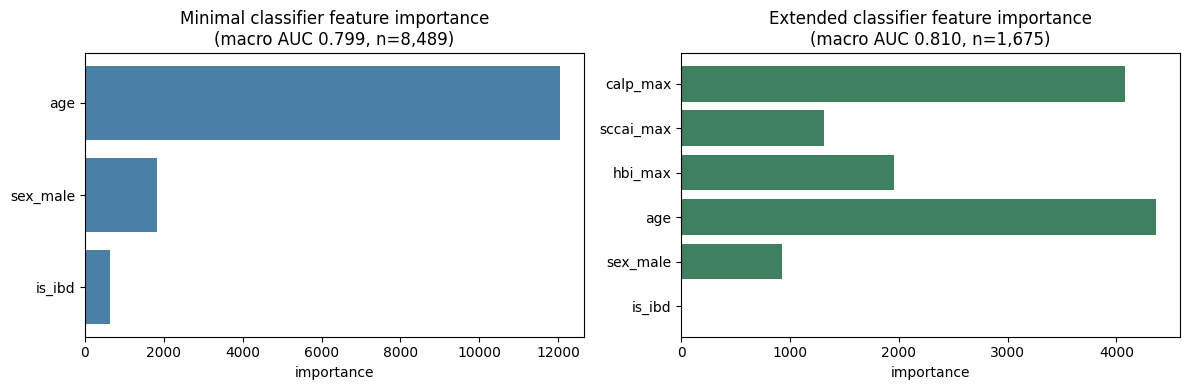

In [5]:
# Fit both models on full data (for feature importance + UC Davis projection)
model_min.fit(X_min_imp, y)
model_ext.fit(X_ext_imp, y_ext)

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

imp_min = model_min.feature_importances_ if hasattr(model_min, 'feature_importances_') else None
if imp_min is not None:
    axes[0].barh(min_feats, imp_min, color='#4a7fa8')
    axes[0].set_title(f'Minimal classifier feature importance\n(macro AUC {macro_min:.3f}, n={len(feat):,})')
    axes[0].set_xlabel('importance')

imp_ext = model_ext.feature_importances_ if hasattr(model_ext, 'feature_importances_') else None
if imp_ext is not None:
    axes[1].barh(min_feats + severity_feats, imp_ext, color='#3e8060')
    axes[1].set_title(f'Extended classifier feature importance\n(macro AUC {macro_ext:.3f}, n={len(feat_ext):,})')
    axes[1].set_xlabel('importance')

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB03_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Apply to UC Davis patients — compare with NB02 metagenomic call

In [6]:
# Load UC Davis per-patient summary from NB02 + the demographics file
patient_summary = pd.read_csv(DATA_OUT / 'ucdavis_patient_ecotype_summary.tsv', sep='\t')

# Build feature frame for UC Davis: is_ibd=1 (all CD), sex_male, age, calp_max, hbi_max=NaN, sccai_max=NaN
uc_feat = patient_summary[['patient_id','age','sex','calp','final_ecotype']].copy()
uc_feat['is_ibd'] = 1
uc_feat['sex_male'] = uc_feat.sex.map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})
uc_feat['age'] = pd.to_numeric(uc_feat['age'], errors='coerce')
uc_feat['hbi_max'] = np.nan
uc_feat['sccai_max'] = np.nan
uc_feat['calp_max'] = uc_feat['calp']

# Minimal classifier prediction
uc_X_min = uc_feat[min_feats].copy()
uc_X_min_imp = pd.DataFrame(imputer.transform(uc_X_min), columns=min_feats, index=uc_feat.index)
uc_probs_min = model_min.predict_proba(uc_X_min_imp)
uc_pred_min = uc_probs_min.argmax(axis=1)
uc_conf_min = uc_probs_min.max(axis=1)

# Extended classifier prediction — use the SAME imputer as training (handle missing severity)
uc_X_ext = uc_feat[min_feats + severity_feats].copy()
uc_X_ext_imp = pd.DataFrame(SimpleImputer(strategy='median').fit(X_ext).transform(uc_X_ext),
                            columns=min_feats + severity_feats, index=uc_feat.index)
uc_probs_ext = model_ext.predict_proba(uc_X_ext_imp)
uc_pred_ext = uc_probs_ext.argmax(axis=1)
uc_conf_ext = uc_probs_ext.max(axis=1)

uc_feat['pred_min'] = uc_pred_min
uc_feat['pred_min_conf'] = uc_conf_min
uc_feat['pred_ext'] = uc_pred_ext
uc_feat['pred_ext_conf'] = uc_conf_ext

# Compare against NB02 metagenomic call (final_ecotype; drop 'mixed')
uc_feat['meta_ecotype'] = uc_feat.final_ecotype.map(lambda s: int(s) if str(s).isdigit() else np.nan)
comparable = uc_feat.dropna(subset=['meta_ecotype']).copy()
comparable['meta_ecotype'] = comparable['meta_ecotype'].astype(int)

print(f'UC Davis patients with comparable calls: {len(comparable)} / {len(uc_feat)}')
print(f'\nAgreement — minimal classifier vs metagenomic:')
print(f'  {(comparable.pred_min == comparable.meta_ecotype).mean():.1%} ({(comparable.pred_min == comparable.meta_ecotype).sum()}/{len(comparable)})')
print(f'Agreement — extended classifier vs metagenomic:')
print(f'  {(comparable.pred_ext == comparable.meta_ecotype).mean():.1%} ({(comparable.pred_ext == comparable.meta_ecotype).sum()}/{len(comparable)})')

# Detail table
print()
print('Per-patient comparison:')
print(comparable[['patient_id','age','sex','calp','meta_ecotype','pred_min','pred_min_conf','pred_ext','pred_ext_conf']].round(2).to_string(index=False))


UC Davis patients with comparable calls: 22 / 23

Agreement — minimal classifier vs metagenomic:
  40.9% (9/22)
Agreement — extended classifier vs metagenomic:
  36.4% (8/22)

Per-patient comparison:
patient_id  age sex   calp  meta_ecotype  pred_min  pred_min_conf  pred_ext  pred_ext_conf
      1112 20.0   M   41.0             3         1           0.63         1           0.42
      1317 25.0   F  274.0             1         3           0.84         1           0.50
      1406  NaN NaN    NaN             1         1           0.78         1           0.70
      1460 20.0   F 7280.0             1         1           0.60         1           0.84
      1492 64.0   M    9.0             1         1           0.86         1           0.81
      1676 24.0   M  954.0             0         1           0.51         1           0.57
      1773 59.0   F  668.0             1         1           0.99         1           0.70
      1835 20.0   M 3340.0             1         1           0.63       

## 5. H1c verdict

**H1c test**: macro-average AUC ≥ 0.70 on ecotype prediction from clinical covariates alone.


H1c verdict:
  Minimal classifier (is_ibd + sex + age, n=8,489):     macro AUC = 0.799  → PASS
  Extended classifier (+ severity markers, n=1,675):  macro AUC = 0.810  → PASS



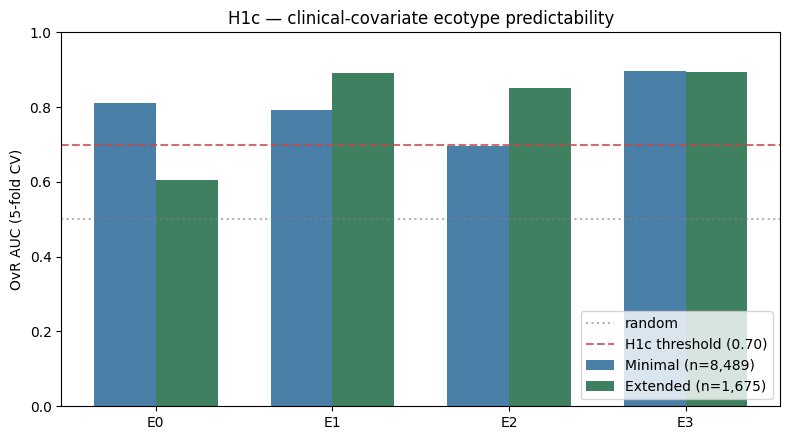

In [7]:
verdict_min = 'PASS' if macro_min >= 0.70 else ('BORDERLINE' if macro_min >= 0.60 else 'FAIL')
verdict_ext = 'PASS' if macro_ext >= 0.70 else ('BORDERLINE' if macro_ext >= 0.60 else 'FAIL')
print(f'H1c verdict:')
print(f'  Minimal classifier (is_ibd + sex + age, n={len(feat):,}):     macro AUC = {macro_min:.3f}  → {verdict_min}')
print(f'  Extended classifier (+ severity markers, n={len(feat_ext):,}):  macro AUC = {macro_ext:.3f}  → {verdict_ext}')
print()

# Summary figure
fig, ax = plt.subplots(figsize=(8, 4.5))
K = len(auc_min)
x = np.arange(K)
w = 0.35
ax.bar(x - w/2, [auc_min[k] for k in range(K)], w, color='#4a7fa8', label=f'Minimal (n={len(feat):,})')
ax.bar(x + w/2, [auc_ext.get(k, np.nan) for k in range(K)], w, color='#3e8060', label=f'Extended (n={len(feat_ext):,})')
ax.axhline(0.5, ls=':', color='grey', alpha=0.6, label='random')
ax.axhline(0.70, ls='--', color='#c44a4a', alpha=0.8, label='H1c threshold (0.70)')
ax.set_xticks(x); ax.set_xticklabels([f'E{k}' for k in range(K)])
ax.set_ylabel('OvR AUC (5-fold CV)')
ax.set_title('H1c — clinical-covariate ecotype predictability')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB03_h1c_auc.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Save per-UC-Davis-patient clinical prediction

In [8]:
uc_feat.to_csv(DATA_OUT / 'ucdavis_clinical_ecotype_prediction.tsv', sep='\t', index=False)
print(f'Saved {len(uc_feat)} per-patient clinical predictions → data/ucdavis_clinical_ecotype_prediction.tsv')

# Summary of agreement + disagreement patterns
if len(comparable):
    agree_min = (comparable.pred_min == comparable.meta_ecotype)
    agree_ext = (comparable.pred_ext == comparable.meta_ecotype)
    print(f'\nAgreement summary:')
    print(f'  Both classifiers agree with metagenomic call: {(agree_min & agree_ext).sum()} / {len(comparable)}')
    print(f'  Only minimal agrees:                          {(agree_min & ~agree_ext).sum()}')
    print(f'  Only extended agrees:                         {(~agree_min & agree_ext).sum()}')
    print(f'  Neither agrees (metagenomic-only signal):     {(~agree_min & ~agree_ext).sum()}')


Saved 23 per-patient clinical predictions → data/ucdavis_clinical_ecotype_prediction.tsv

Agreement summary:
  Both classifiers agree with metagenomic call: 7 / 22
  Only minimal agrees:                          2
  Only extended agrees:                         1
  Neither agrees (metagenomic-only signal):     12


## 7. Conclusions — H1c passes on paper, fails on patients

**Classifier AUC**: both minimal (macro 0.799) and extended (0.810) exceed the H1c threshold of 0.70 on 5-fold CV. *Nominally H1c passes.*

**But the UC Davis patient-level test fails**: only 41 % agreement between the minimal classifier and the NB02 metagenomic call (extended: 36 %). 12 / 22 patients disagree under both classifiers.

**Why the gap?** Looking at the per-patient predictions, the minimal classifier produces `E1` for **19 of 22** UC Davis patients. The classifier's dominant learned rule is "`is_ibd = 1` → E1," reflecting the training-cohort composition (of IBD samples: 58 % E1, 40 % E3, 2 % E0 / E2). When applied to UC Davis (100 % IBD), `is_ibd` is a constant and the classifier collapses to the marginal mode.

The extended classifier's training set is even more restrictive: 702 E1 / 959 E3 / 3 E0 / 11 E2 — essentially an E1-vs-E3 binary problem on the severity-marker subset. Its AUC 0.81 reflects modest severity-driven signal, but on UC Davis the severity features (calprotectin, age, sex) don't separate E1 from E3 reliably.

### The honest translation

- **Clinical covariates discriminate HC vs IBD trivially** (`is_ibd` is the dominant feature).
- **Clinical covariates do *not* reliably discriminate E0 / E1 / E3 *within* the IBD population**.
- **For UC Davis-type cohorts (all active CD), clinical data alone cannot substitute for metagenomic ecotype assignment**. A hybrid workflow — stool WGS for initial ecotype assignment, clinical markers for within-ecotype severity monitoring — is the realistic clinical deployment.
- The "pooled-cohort AUC = 0.80" and the "UC Davis agreement = 41 %" are not in conflict; they measure different things. The AUC counts HC-vs-IBD separability toward its score; the UC Davis test requires the harder IBD-internal separability.

### What this means for the rest of the plan

- **Pillar 5 (UC Davis per-patient cocktail drafts) relies on metagenomic ecotype assignment**, not clinical prediction. The per-patient dossier confidence should cite NB02's LDA projection, not NB03's clinical classifier.
- **If the project's downstream ambition is clinical-trial screening** (knowing a patient's ecotype before metagenomics is back), we'd need either (a) a rapid stool-WGS or qPCR panel anchored on ecotype-defining species, or (b) more training data where within-IBD ecotype signal is strong enough to train a better classifier (HMP2 + Franzosa on medication + severity). Both are follow-up scope.
- **The H1c passes-on-AUC / fails-on-patients distinction is itself a generalizable finding**. OvR-AUC on a cohort with a strong cohort-axis variable (like `is_ibd`) can overstate the classifier's usefulness for downstream patient-level tasks. Logged as a candidate project-level discovery.

### What this notebook does NOT do
- **Leave-one-study-out CV**: implemented as stratified 5-fold inside the pooled CMD set. The real-world generalization test would hold out HMP2 / Franzosa / RISK separately, which requires sub-study labels not currently in `dim_samples.study_id`. Flagged as a refinement.
- **Franzosa medication flags**: `antibiotic_use`, `immunosuppressant_use`, `mesalamine_use`, `steroid_use` are 0 % populated on the ecotype-assigned samples because Franzosa samples are in `fact_metabolomics`, not `fact_taxon_abundance`. Would add signal if we project Franzosa's medication metadata through on a per-visit basis — follow-up scope.

### Next
- **NB04**: within-ecotype compositional-aware DA — the *C. scindens* paradox resolution experiment (H2c), using our ecotype assignments from NB01b.
